# Module import

In [94]:
import numpy as np      
from scipy import ndimage        
from netCDF4 import Dataset        
from scipy.ndimage import zoom, gaussian_filter, label                 
from skimage.transform import resize


import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors   
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Circle, Rectangle
from matplotlib.legend_handler import HandlerPatch

import cartopy.crs as ccrs                              
import cartopy.feature as cfeature     
import cartopy.io.shapereader as shpreader
import sys
sys.path.insert(1, "/home/users/mendrika/SSA/SA/module")
import snflics #type: ignore

import torch 
import torch.nn as nn


import warnings
warnings.filterwarnings("ignore")

from datetime import datetime, timedelta

from scipy.spatial import cKDTree
from matplotlib.colors import ListedColormap

In [95]:
sys.path.append("/home/users/mendrika/Zambia-Intercomparison/models/training")
from zambia_lag_corrected import Core2MapModel

# Choose nowcast origin and lead time (in hour)

In [96]:
year = "2024"
month = "01"
day = "10"
hour = "12"
minute = "00"

In [97]:
lead_time = 1

# Configurations

## Zambia extent

In [98]:
DISPLAY_LON_MIN = 21.167515 + 1
DISPLAY_LON_MAX = 35.316326 - 2
DISPLAY_LAT_MIN = -18.414806 + 0.5
DISPLAY_LAT_MAX = -7.9918404 - 0.1

# Ground truth 

In [99]:
def update_hour(date_dict, hours_to_add, minutes_to_add):
    """
    Add hours and minutes to a datetime dictionary and return the updated dict and a generated file path.

    Args:
        date_dict     (dict): Keys: 'year', 'month', 'day', 'hour', 'minute' as strings, e.g. "01", "23"
        hours_to_add   (int): Number of hours to add.
        minutes_to_add (int): Number of minutes to add.

    Returns:
        tuple:
            - dict: Updated datetime dictionary with all fields as zero-padded strings.
            - str: File path in the format YYYY/MM/YYYYMMDDHHMM.nc
    """
    # Parse the original time
    time_obj = datetime(
        int(date_dict["year"]),
        int(date_dict["month"]),
        int(date_dict["day"]),
        int(date_dict["hour"]),
        int(date_dict["minute"])
    )

    # Add hours
    updated = time_obj + timedelta(hours=hours_to_add, minutes=minutes_to_add)

    # Format updated dictionary
    new_date_dict = {
        "year":   f"{updated.year:04d}",
        "month":  f"{updated.month:02d}",
        "day":    f"{updated.day:02d}",
        "hour":   f"{updated.hour:02d}",
        "minute": f"{updated.minute:02d}"
    }

    # Generate file path
    file_path = f"{new_date_dict['year']}/{new_date_dict['month']}/{new_date_dict['year']}{new_date_dict['month']}{new_date_dict['day']}{new_date_dict['hour']}{new_date_dict['minute']}.nc"

    return {'time': new_date_dict, 'path': file_path}

In [100]:
def load_wavelet_dataset(year, month, day, hour, minute, lead_time):
    
    nowcast_origin = {
        "year":   year,
        "month":  month,
        "day":    day,
        "hour":   hour,
        "minute": minute,
    }

    nowcast_lt = update_hour(nowcast_origin, hours_to_add=lead_time, minutes_to_add=0)["time"]

    path_core = f"/gws/nopw/j04/cocoon/SSA_domain/ch9_wavelet/{nowcast_lt['year']}/{nowcast_lt['month']}"
    file = f"{path_core}/{nowcast_lt['year']}{nowcast_lt['month']}{nowcast_lt['day']}{nowcast_lt['hour']}{nowcast_lt['minute']}.nc"
    return Dataset(file, mode='r')["cores"]

# ZCAST

In [101]:
y_min, y_max = 580, 930
x_min, x_max = 1480, 1850

In [102]:
geodata = np.load("/gws/nopw/j04/cocoon/SSA_domain/lat_lon_2268_2080.npz")
Zambia_lons = geodata["lon"][y_min:y_max, x_min:x_max]
Zambia_lats = geodata["lat"][y_min:y_max, x_min:x_max]

In [103]:
def load_zcast_input(year, month, day, hour, minute, lead_time):
    input_path_zcast = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/raw/inputs_t0"
    output_path_zcast = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/raw/targets_t{lead_time}"
    core_input = f"{input_path_zcast}/input-{year}{month}{day}_{hour}{minute}.pt"
    return torch.load(core_input)
    

In [104]:
CHECKPOINT_PATH = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/checkpoints/t{lead_time}/best-core2map.ckpt"
SCALER_PATH = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/scaling/scaler_realcores.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

[
    lat, lon,
    lat_min, lat_max,
    lon_min, lon_max,
    tir, size,
    mask, time_lag
]

In [105]:
model = Core2MapModel.load_from_checkpoint(CHECKPOINT_PATH, map_location=DEVICE)
model.eval()
model.to(DEVICE)

scaler = torch.load(SCALER_PATH, weights_only=False)
mean = np.asarray(scaler["mean"])   # shape (8,)
scale = np.asarray(scaler["scale"]) # shape (8,)

COLS_TO_SCALE = [0, 1, 2, 3, 4, 5, 6, 7]
MASK_COL_INDEX = 8
LAG_COL_INDEX = 9

In [106]:
zcast_input = load_zcast_input(year, month, day, hour, minute, lead_time)

In [107]:
input_tensor = zcast_input["input_tensor"].clone().unsqueeze(0)
global_context = zcast_input["global_context"].clone().unsqueeze(0)


In [108]:
if input_tensor.shape == (1, 288, 10):
    # Convert mean/scale to tensors on the right device
    mean_t = torch.tensor(mean, dtype=input_tensor.dtype, device=input_tensor.device)
    scale_t = torch.tensor(scale, dtype=input_tensor.dtype, device=input_tensor.device)

    # Scale only real cores (mask == 1)
    mask = input_tensor[:, :, MASK_COL_INDEX] > 0.5
    for col in COLS_TO_SCALE:
        x = input_tensor[:, :, col]
        x[mask] = (x[mask] - mean_t[col]) / scale_t[col]
        input_tensor[:, :, col] = x

    # Normalise lag column to [-1, 1]
    input_tensor[:, :, LAG_COL_INDEX] = 2 * (input_tensor[:, :, LAG_COL_INDEX] / 120) - 1

else:
    sys.exit("Something wrong with the input")

# Compute Attention Maps

In [109]:
attn_maps = []

# --- MultiheadAttention subclass that stores weights but does not set need_weights itself
class MultiheadAttentionWithWeights(nn.MultiheadAttention):
    def __init__(self, *args, store_list=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.store = store_list

    def forward(self, query, key, value, **kwargs):
        # Let caller control need_weights; we just record if provided
        out, w = super().forward(query, key, value, **kwargs)
        if isinstance(w, torch.Tensor) and self.store is not None:
            self.store.append(w.detach().cpu())
        return out, w


def enable_encoder_attn_capture(model, store_list):
    for i, layer in enumerate(model.transformer.layers):
        old_mha = layer.self_attn
        new_mha = MultiheadAttentionWithWeights(
            embed_dim=old_mha.embed_dim,
            num_heads=old_mha.num_heads,
            dropout=old_mha.dropout,
            batch_first=getattr(old_mha, "batch_first", True),
            store_list=store_list
        )
        new_mha.load_state_dict(old_mha.state_dict())
        layer.self_attn = new_mha

        # override each layer forward to always request weights
        def new_forward(self, src, *args, **kwargs):
            src2, _ = self.self_attn(
                src, src, src,
                attn_mask=kwargs.get("attn_mask", None),
                key_padding_mask=kwargs.get("src_key_padding_mask", None),
                need_weights=True,
                average_attn_weights=False
            )
            src = src + self.dropout1(src2)
            src = self.norm1(src)
            src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
            src = src + self.dropout2(src2)
            src = self.norm2(src)
            return src

        layer.forward = new_forward.__get__(layer, type(layer))
        print(f"Replaced self_attn and forward in transformer.layers.{i}")


# Apply patch
enable_encoder_attn_capture(model, attn_maps)

# Forward pass to capture attention weights
with torch.no_grad():
    zcast = torch.sigmoid(
        model(input_tensor.to(DEVICE), global_context.to(DEVICE))
    ).squeeze(0).squeeze(0).detach().cpu().numpy()

# Inspect captured attention maps
if attn_maps:
    print(f"Captured {len(attn_maps)} attention layers.")
    for i, w in enumerate(attn_maps):
        print(f"Layer {i}: {tuple(w.shape)}")
else:
    print("No attention maps captured.")


Replaced self_attn and forward in transformer.layers.0
Replaced self_attn and forward in transformer.layers.1
Replaced self_attn and forward in transformer.layers.2
Replaced self_attn and forward in transformer.layers.3
Captured 4 attention layers.
Layer 0: (1, 4, 288, 288)
Layer 1: (1, 4, 288, 288)
Layer 2: (1, 4, 288, 288)
Layer 3: (1, 4, 288, 288)


# Attention score

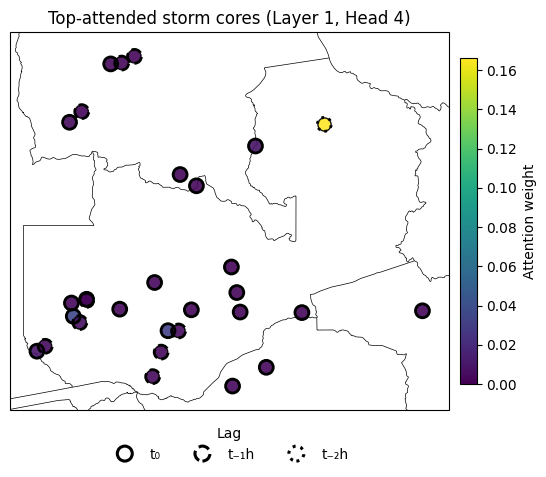

In [110]:
# constants
NB_CORES = 96
lag_groups = np.repeat([0, 60, 120], NB_CORES)
LAT_COL_INDEX = 0
LON_COL_INDEX = 1

# mean attention for one layer/head
layer_idx, head_idx = 0, 3
attn = attn_maps[layer_idx][0, head_idx]  # (288, 288)
token_importance = attn.mean(0).numpy()

# select top tokens
top_idx = np.argsort(token_importance)[-30:]
lat_norm = input_tensor[0, top_idx, LAT_COL_INDEX].cpu().numpy()
lon_norm = input_tensor[0, top_idx, LON_COL_INDEX].cpu().numpy()
lag = lag_groups[top_idx]
att = token_importance[top_idx]

# de-normalise
lat_real = lat_norm * scale[LAT_COL_INDEX] + mean[LAT_COL_INDEX]
lon_real = lon_norm * scale[LON_COL_INDEX] + mean[LON_COL_INDEX]

# balanced colour normalisation
mean_att, std_att = np.mean(att), np.std(att)
vmin = max(0.0, mean_att - std_att)
vmax = mean_att + std_att
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

# figure and axis
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="white")

# per-lag styles
styles = {
    0: {"label": "t₀", "linestyle": "solid"},
    60: {"label": "t₋₁h", "linestyle": "--"},
    120: {"label": "t₋₂h", "linestyle": ":"},
}

# plot per lag group
for lag_val, style in styles.items():
    sel = lag == lag_val
    if not np.any(sel):
        continue

    ax.scatter(
        lon_real[sel], lat_real[sel],
        c=att[sel], cmap=cmap, norm=norm,
        s=90, transform=ccrs.PlateCarree(),
        alpha=0.9, zorder=3,
        edgecolors="black", linewidth=1.0,
    )

    for lon, lat in zip(lon_real[sel], lat_real[sel]):
        circ = plt.Circle(
            (lon, lat), 0.2,
            transform=ccrs.PlateCarree(),
            fill=False,  # hollow
            facecolor="none",  # explicitly none
            edgecolor="black",
            linewidth=2.0,
            linestyle=style["linestyle"],
            zorder=4,
        )
        ax.add_patch(circ)

# vertical colourbar
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Attention weight")

# hollow legend circles
legend_handles = [
    Circle(
        (0, 0),
        radius=0.5,
        facecolor="none",  # ensures unfilled
        edgecolor="black",
        linewidth=2.2,
        linestyle=style["linestyle"],
        label=style["label"],
    )
    for style in styles.values()
]

# ensure the legend also has no fill
def make_hollow_circle(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    center = width / 2 - xdescent, height / 2 - ydescent
    p = Circle(
        center,
        radius=height / 1.3,
        facecolor="none",  # guaranteed no fill
        edgecolor=orig_handle.get_edgecolor(),
        linestyle=orig_handle.get_linestyle(),
        linewidth=orig_handle.get_linewidth(),
    )
    return p

# legend below figure
ax.legend(
    handles=legend_handles,
    title="Lag",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=3,
    frameon=False,
    handler_map={Circle: HandlerPatch(patch_func=make_hollow_circle)},
)

ax.set_title(f"Top-attended storm cores (Layer {layer_idx+1}, Head {head_idx+1})")
plt.subplots_adjust(bottom=0.25)
plt.show()


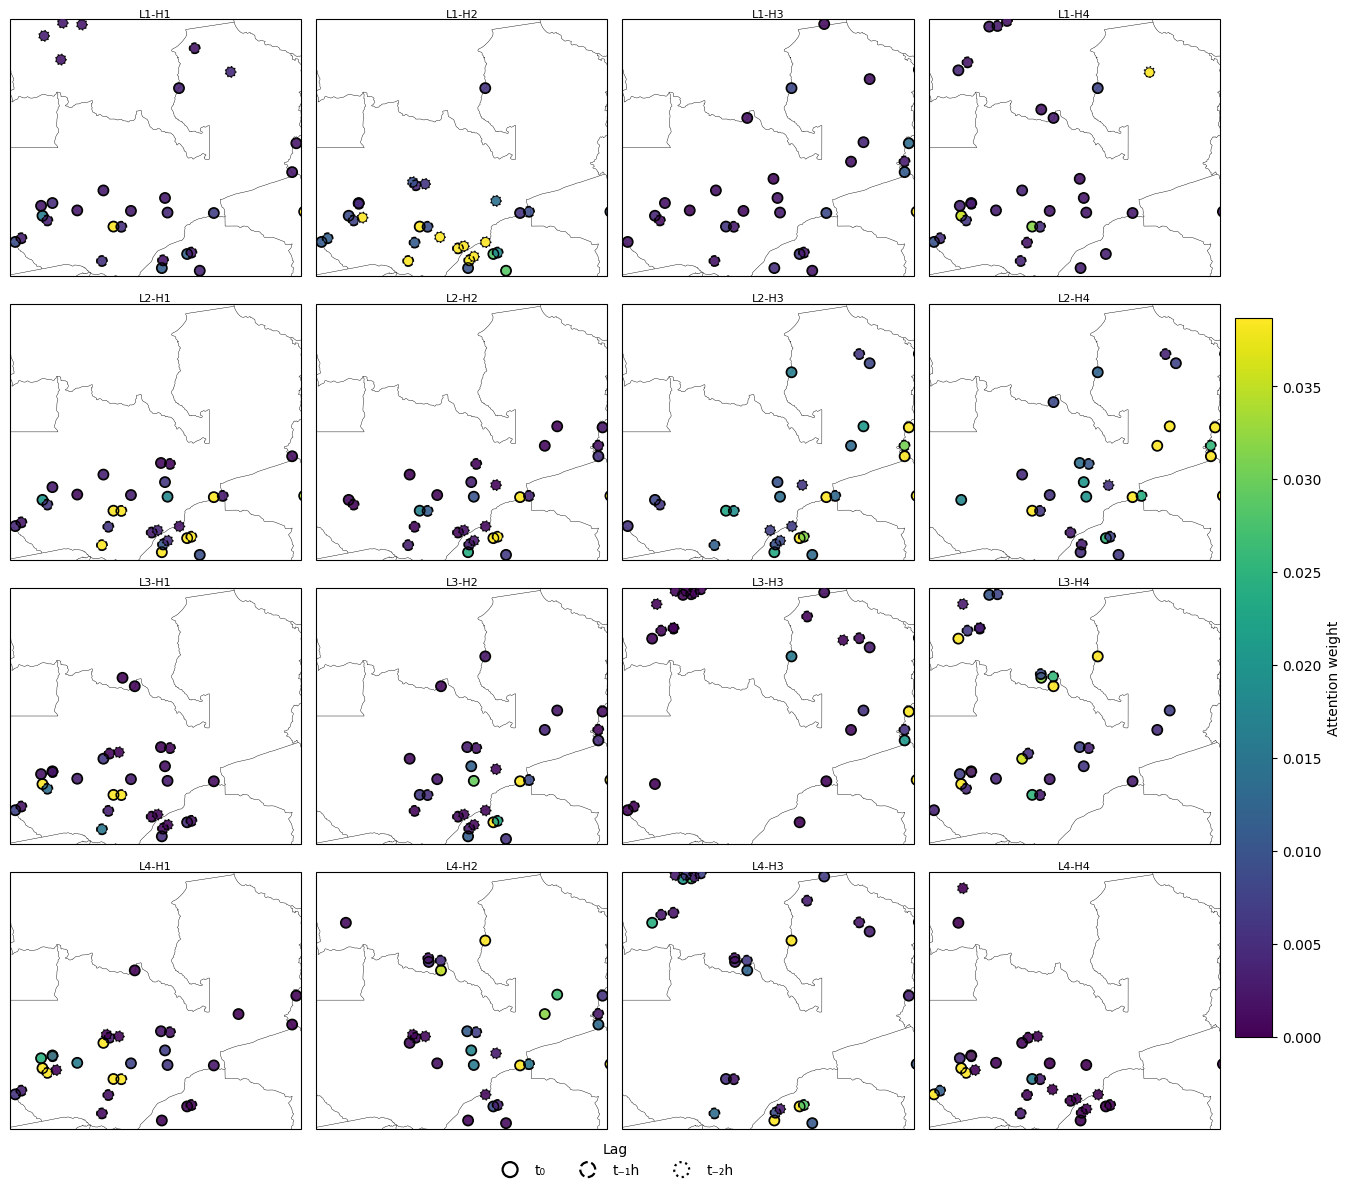

In [111]:
# constants
NB_CORES = 96
lag_groups = np.repeat([0, 60, 120], NB_CORES)
LAT_COL_INDEX = 0
LON_COL_INDEX = 1

# fixed extent
MAP_EXTENT = [DISPLAY_LON_MIN, DISPLAY_LON_MAX, DISPLAY_LAT_MIN, DISPLAY_LAT_MAX]

# global colour limits
all_att_values = []
for l in range(len(attn_maps)):
    for h in range(attn_maps[l].shape[1]):
        att = attn_maps[l][0, h].mean(0).numpy()
        all_att_values.extend(att)
all_att_values = np.array(all_att_values)
mean_att, std_att = np.mean(all_att_values), np.std(all_att_values)
vmin = max(0.0, mean_att - std_att)
vmax = mean_att + std_att
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

# figure layout
n_layers = len(attn_maps)
n_heads = attn_maps[0].shape[1]
fig, axes = plt.subplots(
    n_layers, n_heads,
    figsize=(3.1 * n_heads, 2.9 * n_layers),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# lag styles
styles = {
    0: {"label": "t₀", "linestyle": "solid"},
    60: {"label": "t₋₁h", "linestyle": "--"},
    120: {"label": "t₋₂h", "linestyle": ":"},
}

# plot
for i, layer_idx in enumerate(range(n_layers)):
    for j, head_idx in enumerate(range(n_heads)):
        ax = axes[i, j] if n_layers > 1 else axes[j]
        attn = attn_maps[layer_idx][0, head_idx]
        token_importance = attn.mean(0).numpy()
        top_idx = np.argsort(token_importance)[-30:]

        lat_norm = input_tensor[0, top_idx, LAT_COL_INDEX].cpu().numpy()
        lon_norm = input_tensor[0, top_idx, LON_COL_INDEX].cpu().numpy()
        lag = lag_groups[top_idx]
        att = token_importance[top_idx]

        lat_real = lat_norm * scale[LAT_COL_INDEX] + mean[LAT_COL_INDEX]
        lon_real = lon_norm * scale[LON_COL_INDEX] + mean[LON_COL_INDEX]

        ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor="white")

        for lag_val, style in styles.items():
            sel = lag == lag_val
            if not np.any(sel):
                continue
            ax.scatter(
                lon_real[sel], lat_real[sel],
                c=att[sel], cmap=cmap, norm=norm,
                s=45, transform=ccrs.PlateCarree(),
                alpha=0.9, zorder=3,
                edgecolors="black", linewidth=0.7,
            )
            for lon, lat in zip(lon_real[sel], lat_real[sel]):
                circ = Circle(
                    (lon, lat), 0.2,
                    transform=ccrs.PlateCarree(),
                    fill=False, facecolor="none",
                    edgecolor="black",
                    linewidth=1.0,
                    linestyle=style["linestyle"],
                    zorder=4,
                )
                ax.add_patch(circ)

        ax.set_title(f"L{layer_idx+1}-H{head_idx+1}", fontsize=8, pad=1)
        ax.set_xticks([]); ax.set_yticks([])

# detached colourbar (slimmer and aligned)
cbar_ax = fig.add_axes([1, 0.1, 0.03, 0.62])
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="vertical")
cbar.set_label("Attention weight")

# hollow legend circles
legend_handles = [
    Circle(
        (0, 0),
        radius=0.5,
        facecolor="none",
        edgecolor="black",
        linewidth=1.6,
        linestyle=style["linestyle"],
        label=style["label"],
    )
    for style in styles.values()
]

def make_hollow_circle(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    center = width / 2 - xdescent, height / 2 - ydescent
    return Circle(
        center,
        radius=height / 1.3,
        facecolor="none",
        edgecolor=orig_handle.get_edgecolor(),
        linestyle=orig_handle.get_linestyle(),
        linewidth=orig_handle.get_linewidth(),
    )

# compact legend directly below the grid
fig.legend(
    handles=legend_handles,
    title="Lag",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=False,
    handler_map={Circle: HandlerPatch(patch_func=make_hollow_circle)},
)

plt.subplots_adjust(left=0.05, right=0.9, bottom=0.07, top=0.93, wspace=0.03, hspace=0.03)
plt.tight_layout()
plt.show()

# Visualisation - Past Frames and Nowcasts

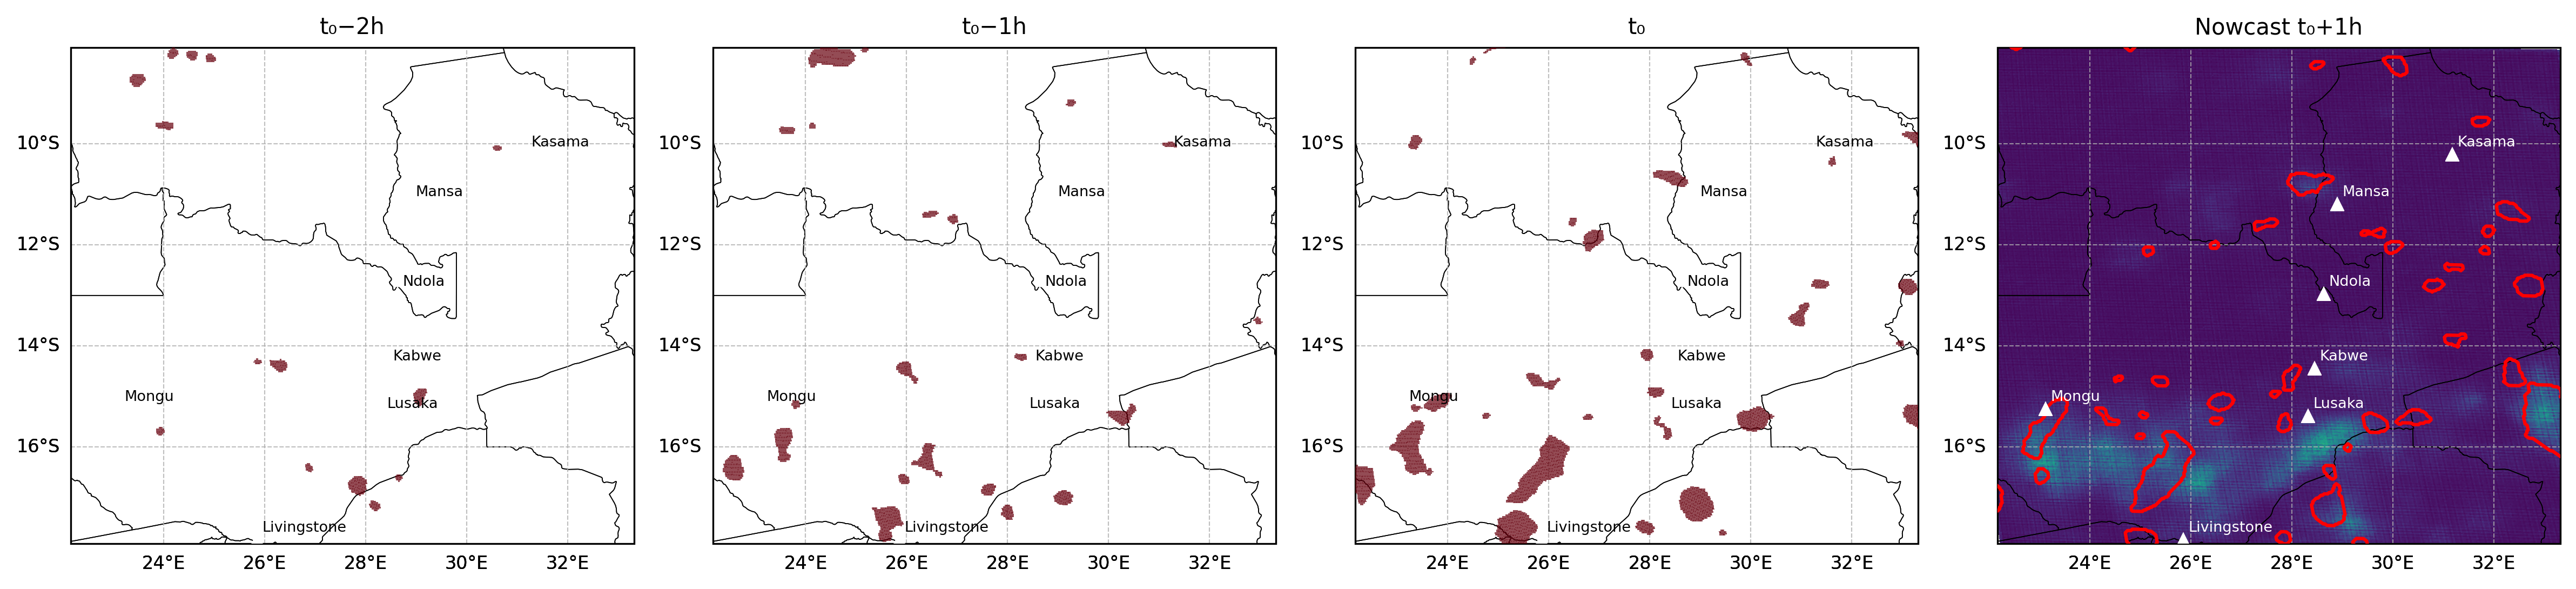

In [112]:
# --- Load data ---
frames = {
    "t₀−2h": load_wavelet_dataset(year, month, day, hour, minute, -2)[0, y_min:y_max, x_min:x_max] != 0,
    "t₀−1h": load_wavelet_dataset(year, month, day, hour, minute, -1)[0, y_min:y_max, x_min:x_max] != 0,
    "t₀":    load_wavelet_dataset(year, month, day, hour, minute,  0)[0, y_min:y_max, x_min:x_max] != 0,
}
ground_truth = load_wavelet_dataset(year, month, day, hour, minute, lead_time)[0, y_min:y_max, x_min:x_max] != 0

# --- City locations ---
locations = {
    "Lusaka": [-15.3875, 28.3228],
    "Ndola": [-12.9683, 28.6366],
    "Kasama": [-10.2129, 31.1808],
    "Kabwe": [-14.4469, 28.4464],
    "Livingstone": [-17.8419, 25.8542],
    "Mongu": [-15.2484, 23.1274],
    "Mansa": [-11.1996, 28.8943],
}

# --- Common extent for all panels ---
extent = [DISPLAY_LON_MIN, DISPLAY_LON_MAX, DISPLAY_LAT_MIN, DISPLAY_LAT_MAX]

# --- Create figure with 4 panels ---
fig, axes = plt.subplots(
    1, 4, figsize=(16, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)
titles = list(frames.keys()) + [f"Nowcast t₀+{lead_time}h"]

# --- Shared base map setup ---
def setup_map(ax, title):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.4)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.4)
    ax.set_title(title, fontsize=10)
    gl = ax.gridlines(
            draw_labels=True, alpha=0.4, linestyle='--', linewidth=0.5, 
            xlocs=np.arange(np.floor(DISPLAY_LON_MIN), np.ceil(DISPLAY_LON_MAX), 2),
            ylocs=np.arange(np.floor(DISPLAY_LAT_MIN), np.ceil(DISPLAY_LAT_MAX), 2)
            )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}


for i, ax in enumerate(axes):
    setup_map(ax, titles[i])
    if i != 0:
        # Disable y-axis labels/ticks for all except the first
        gl = ax.gridlines(
            draw_labels=True, alpha=0.4, linestyle='--', linewidth=0.5, 
            xlocs=np.arange(np.floor(DISPLAY_LON_MIN), np.ceil(DISPLAY_LON_MAX), 2),
            ylocs=np.arange(np.floor(DISPLAY_LAT_MIN), np.ceil(DISPLAY_LAT_MAX), 2)
            )
        gl.top_labels = False
        gl.left_labels = False
        gl.right_labels = False
    else:
        gl = ax.gridlines(
            draw_labels=True, alpha=0.4, linestyle='--', linewidth=0.5, 
            xlocs=np.arange(np.floor(DISPLAY_LON_MIN), np.ceil(DISPLAY_LON_MAX), 2),
            ylocs=np.arange(np.floor(DISPLAY_LAT_MIN), np.ceil(DISPLAY_LAT_MAX), 2)
            )
        gl.left_labels = True
        gl.right_labels = False
        gl.top_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}


# --- First three panels (past frames) ---
for ax, (title, mask) in zip(axes[:3], frames.items()):
    setup_map(ax, title)
    masked = np.ma.masked_where(mask == 0, mask)
    ax.pcolormesh(
        Zambia_lons, Zambia_lats, masked,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=0, vmax=1,
        alpha=0.7, zorder=3
    )

# --- Fourth panel (nowcast + ground truth) ---
ax = axes[3]
setup_map(ax, f"Nowcast t₀+{lead_time}h")

# Nowcast background
ZCAST_masked = np.ma.masked_where(zcast <= 0, zcast)

# Ensure 2D shape (lat, lon)
if ZCAST_masked.ndim > 2:
    ZCAST_masked = np.squeeze(ZCAST_masked)
elif ZCAST_masked.ndim == 1:
    raise ValueError("zcast must be at least 2D (lat, lon).")

im = ax.pcolormesh(
    Zambia_lons, Zambia_lats, ZCAST_masked,
    cmap='viridis', vmin=0, vmax=1,
    transform=ccrs.PlateCarree(), zorder=1
)

# Ground truth contour
gt_smooth = gaussian_filter(ground_truth.astype(float), sigma=0.4)
ax.contour(
    Zambia_lons, Zambia_lats, gt_smooth,
    levels=[0.5], colors='red', linewidths=1.5,
    transform=ccrs.PlateCarree(), zorder=5
)

# --- Plot city markers on each panel ---
for i, ax in enumerate(axes):
    text_color = "black" if i < 3 else "white"
    for name, (lat, lon) in locations.items():
        ax.plot(lon, lat, marker="^", color="white", markersize=5,
                transform=ccrs.PlateCarree(), zorder=6)
        ax.text(lon + 0.1, lat + 0.1, name, fontsize=6.5,
                transform=ccrs.PlateCarree(), ha='left', va='bottom',
                color=text_color, zorder=6)

# --- Vertical colourbar only for last axis ---
# cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.01, pad=0.04)
# cbar.set_label('Probability of convective cores', fontsize=9)

plt.tight_layout()
plt.show()

# Visualisation - Important Storms

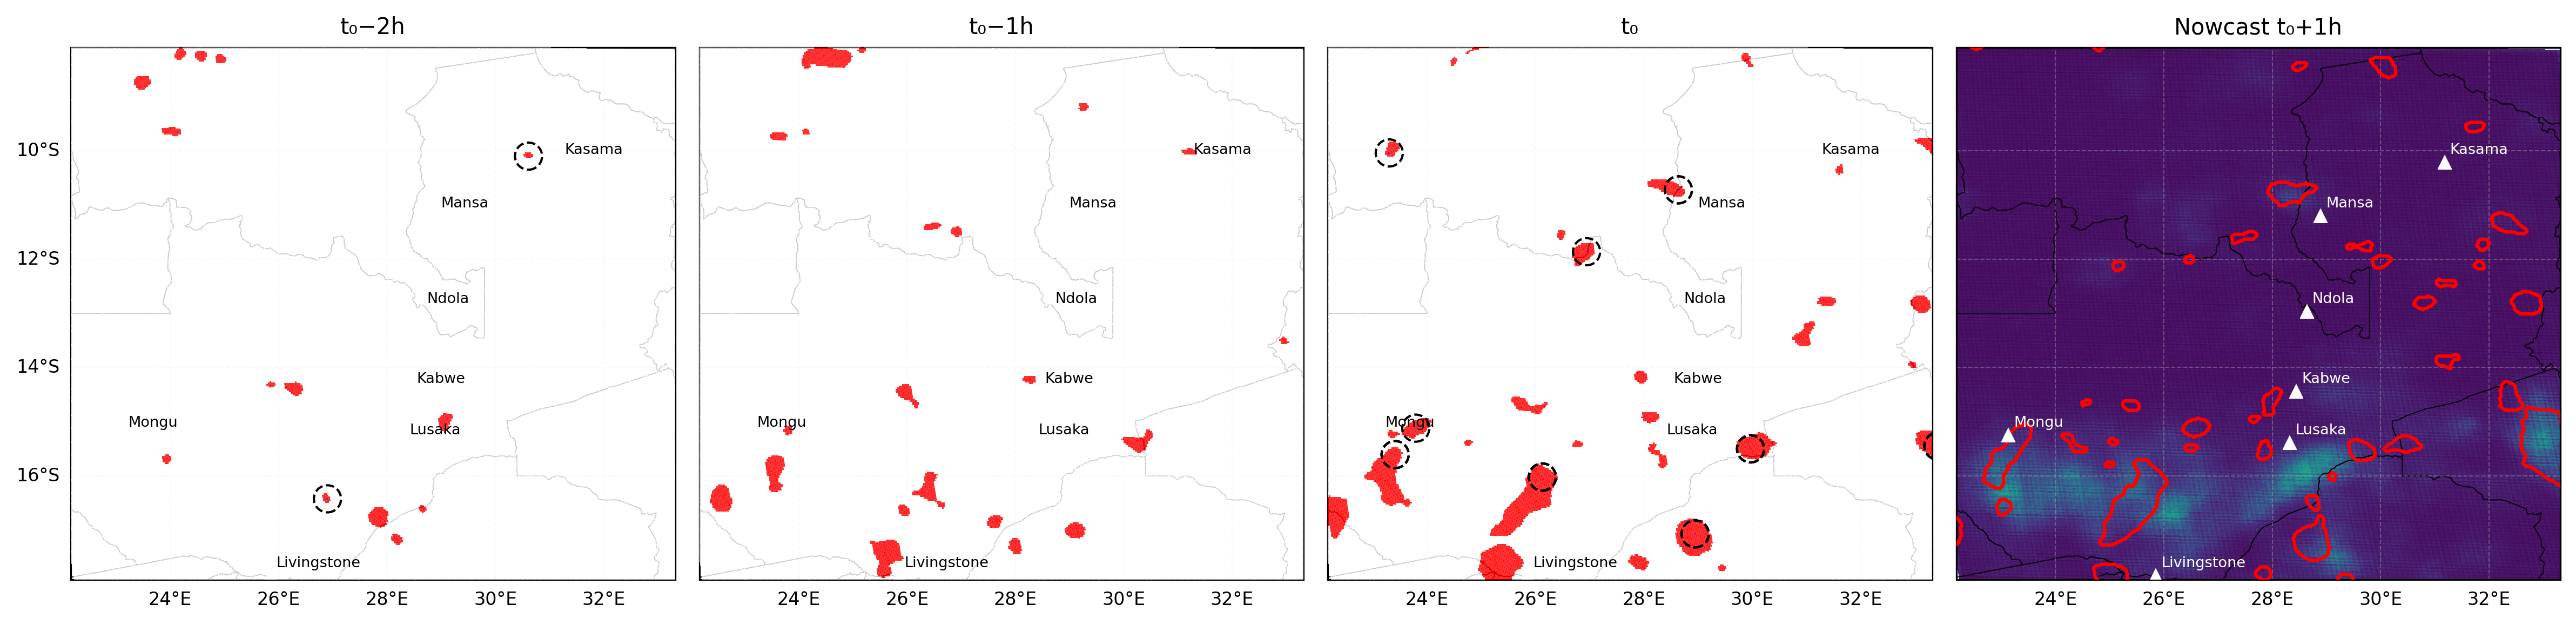

In [113]:
# --- Common extent for all panels ---
extent = [DISPLAY_LON_MIN, DISPLAY_LON_MAX, DISPLAY_LAT_MIN, DISPLAY_LAT_MAX]

# --- Create figure with 4 panels ---
fig, axes = plt.subplots(
    1, 4, figsize=(16, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)
titles = list(frames.keys()) + [f"Nowcast t₀+{lead_time}h"]

# --- Shared base map setup ---
def setup_map(ax, title):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.4)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.4)
    ax.set_title(title, fontsize=10)

# --- Set gridlines for each subplot ---
for i, ax in enumerate(axes):
    setup_map(ax, titles[i])
    gl = ax.gridlines(
        draw_labels=True, alpha=0.4, linestyle='--', linewidth=0.5,
        xlocs=np.arange(np.floor(DISPLAY_LON_MIN), np.ceil(DISPLAY_LON_MAX), 2),
        ylocs=np.arange(np.floor(DISPLAY_LAT_MIN), np.ceil(DISPLAY_LAT_MAX), 2)
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i == 0)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

# ---------------------------------------------------------------------
# Attention data: recolour important storms (att > 0.1) and circle them
# ---------------------------------------------------------------------
att_values, lat_vals, lon_vals, lag_vals = [], [], [], []
for l in range(len(attn_maps)):
    for h in range(attn_maps[l].shape[1]):
        att = attn_maps[l][0, h].mean(0).numpy()
        top_idx = np.argsort(att)[-30:]
        lat_norm = input_tensor[0, top_idx, LAT_COL_INDEX].cpu().numpy()
        lon_norm = input_tensor[0, top_idx, LON_COL_INDEX].cpu().numpy()
        lag = lag_groups[top_idx]
        lat_real = lat_norm * scale[LAT_COL_INDEX] + mean[LAT_COL_INDEX]
        lon_real = lon_norm * scale[LON_COL_INDEX] + mean[LON_COL_INDEX]
        att_values.extend(att[top_idx])
        lat_vals.extend(lat_real)
        lon_vals.extend(lon_real)
        lag_vals.extend(lag)

att_values = np.array(att_values)
lat_vals = np.array(lat_vals)
lon_vals = np.array(lon_vals)
lag_vals = np.array(lag_vals)

# Define colour map: 0=white, 1=normal red, 2=important purple
cmap = ListedColormap(["white", "red", "purple"])

# Map lag values to each panel
lag_to_panel = {120: 0, 60: 1, 0: 2}

for lag_val, (title, mask) in zip([120, 60, 0], frames.items()):
    ax = axes[lag_to_panel[lag_val]]
    setup_map(ax, title)

    display = np.zeros_like(mask, dtype=int)
    display[mask] = 1  # red by default

    # Select attention cores for this lag with att > 0.1
    high = (lag_vals == lag_val) & (att_values > 0.1)
    if np.any(high):
        # Build KD-tree using (lon, lat)
        tree = cKDTree(np.c_[Zambia_lons.ravel(), Zambia_lats.ravel()])
        pts = np.c_[lon_vals[high], lat_vals[high]]
        dist, idx = tree.query(pts, k=1)

        # Only recolour nearby grid cells (within 0.2°)
        important_mask = np.zeros_like(display, dtype=bool).ravel()
        important_mask[idx[dist < 0.2]] = True
        important_mask = important_mask.reshape(display.shape)

        # Apply recolouring only inside existing storm regions
        display[(important_mask) & (mask)] = 2  # purple = important storm

        # Draw same dashed black circle for all important cores
        for lon, lat in zip(lon_vals[high], lat_vals[high]):
            circ = Circle(
                (lon, lat), 0.25,
                transform=ccrs.PlateCarree(),
                fill=False,
                facecolor="none",
                edgecolor="black",
                linewidth=1.0,
                linestyle='--',  # same dashed style for all lags
                zorder=9
            )
            ax.add_patch(circ)

    ax.pcolormesh(
        Zambia_lons, Zambia_lats, display,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=0, vmax=2,
        alpha=0.8, zorder=3
    )

# ---------------------------------------------------------------------
# Fourth panel: nowcast + ground truth
# ---------------------------------------------------------------------
ax = axes[3]
setup_map(ax, f"Nowcast t₀+{lead_time}h")

ZCAST_masked = np.ma.masked_where(zcast <= 0, zcast)
if ZCAST_masked.ndim > 2:
    ZCAST_masked = np.squeeze(ZCAST_masked)
elif ZCAST_masked.ndim == 1:
    raise ValueError("zcast must be at least 2D (lat, lon).")

im = ax.pcolormesh(
    Zambia_lons, Zambia_lats, ZCAST_masked,
    cmap='viridis', vmin=0, vmax=1,
    transform=ccrs.PlateCarree(), zorder=1
)

gt_smooth = gaussian_filter(ground_truth.astype(float), sigma=0.4)
ax.contour(
    Zambia_lons, Zambia_lats, gt_smooth,
    levels=[0.5], colors='red', linewidths=1.5,
    transform=ccrs.PlateCarree(), zorder=5
)

# ---------------------------------------------------------------------
# City markers
# ---------------------------------------------------------------------
for i, ax in enumerate(axes):
    text_color = "black" if i < 3 else "white"
    for name, (lat, lon) in locations.items():
        ax.plot(lon, lat, marker="^", color="white", markersize=5,
                transform=ccrs.PlateCarree(), zorder=6)
        ax.text(lon + 0.1, lat + 0.1, name, fontsize=6.5,
                transform=ccrs.PlateCarree(), ha='left', va='bottom',
                color=text_color, zorder=6)


plt.tight_layout()
plt.show()


# Visualisation- Change Colours of Important Storms

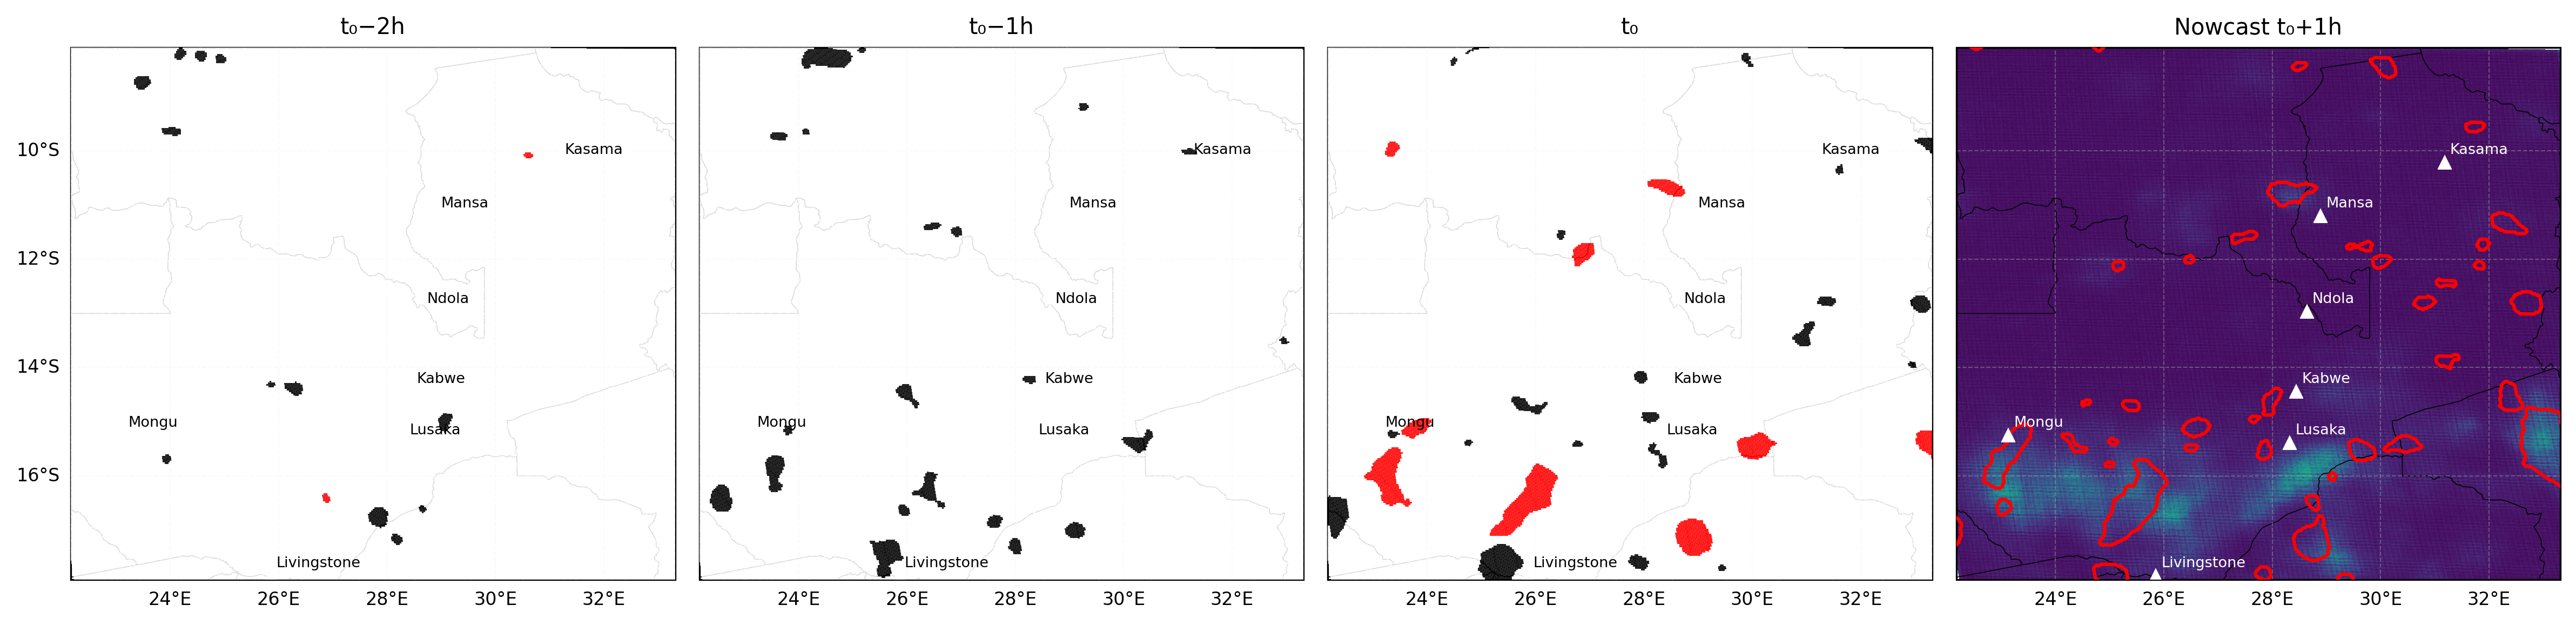

In [116]:
# ---------------------------------------------------------------------
# Compute importance mask per lag (entire storm coloured)
# ---------------------------------------------------------------------
ATT_THRESHOLD = 0.1
DIST_THRESHOLD = 0.2  # degrees

grid_points = np.c_[Zambia_lons.ravel(), Zambia_lats.ravel()]
tree = cKDTree(grid_points)

att_values, lat_vals, lon_vals, lag_vals = [], [], [], []
for l in range(len(attn_maps)):
    for h in range(attn_maps[l].shape[1]):
        att = attn_maps[l][0, h].mean(0).numpy()
        top_idx = np.argsort(att)[-30:]
        lat_norm = input_tensor[0, top_idx, LAT_COL_INDEX].cpu().numpy()
        lon_norm = input_tensor[0, top_idx, LON_COL_INDEX].cpu().numpy()
        lag = lag_groups[top_idx]
        lat_real = lat_norm * scale[LAT_COL_INDEX] + mean[LAT_COL_INDEX]
        lon_real = lon_norm * scale[LON_COL_INDEX] + mean[LON_COL_INDEX]
        att_values.extend(att[top_idx])
        lat_vals.extend(lat_real)
        lon_vals.extend(lon_real)
        lag_vals.extend(lag)

att_values = np.array(att_values)
lat_vals = np.array(lat_vals)
lon_vals = np.array(lon_vals)
lag_vals = np.array(lag_vals)

important_per_lag = {}
for lag_val, obs_mask in zip([120, 60, 0], frames.values()):
    labelled_storms, n_storms = label(obs_mask)
    important_mask = np.zeros_like(obs_mask, dtype=bool)

    if n_storms > 0:
        sel = (lag_vals == lag_val) & (att_values > ATT_THRESHOLD)
        if np.any(sel):
            pts = np.c_[lon_vals[sel], lat_vals[sel]]
            dist, idx = tree.query(pts, k=1)
            valid = dist < DIST_THRESHOLD
            if np.any(valid):
                hit_labels = np.unique(labelled_storms.ravel()[idx[valid]])
                hit_labels = hit_labels[hit_labels > 0]
                important_mask = np.isin(labelled_storms, hit_labels)

    important_per_lag[lag_val] = important_mask

# ---------------------------------------------------------------------
# Plot 4 panels: 3 lags (importance masks) + nowcast
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 4, figsize=(16, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)
titles = ["t₀−2h", "t₀−1h", "t₀", f"Nowcast t₀+{lead_time}h"]
lags = [120, 60, 0]
cmap = ListedColormap(["white", "black", "red"])

def setup_map(ax, title):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.4)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.4)
    ax.set_title(title, fontsize=10)

# Add gridlines for all panels
for i, ax in enumerate(axes):
    setup_map(ax, titles[i])
    gl = ax.gridlines(
        draw_labels=True, alpha=0.4, linestyle='--', linewidth=0.5,
        xlocs=np.arange(np.floor(DISPLAY_LON_MIN), np.ceil(DISPLAY_LON_MAX), 2),
        ylocs=np.arange(np.floor(DISPLAY_LAT_MIN), np.ceil(DISPLAY_LAT_MAX), 2)
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i == 0)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

# Plot importance masks per lag
for ax, lag_val, title in zip(axes[:3], lags, titles[:3]):
    obs_mask = frames[title]
    imp_mask = important_per_lag[lag_val]

    display = np.zeros_like(obs_mask, dtype=int)
    display[obs_mask] = 1
    display[imp_mask] = 2

    ax.pcolormesh(
        Zambia_lons, Zambia_lats, display,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=0, vmax=2,
        alpha=0.85, zorder=3
    )

# Fourth panel: nowcast + ground truth
ax = axes[3]
ZCAST_masked = np.ma.masked_where(zcast <= 0, zcast)
ZCAST_masked = np.squeeze(ZCAST_masked)
im = ax.pcolormesh(
    Zambia_lons, Zambia_lats, ZCAST_masked,
    cmap='viridis', vmin=0, vmax=1,
    transform=ccrs.PlateCarree(), zorder=1
)

gt_smooth = gaussian_filter(ground_truth.astype(float), sigma=0.4)
ax.contour(
    Zambia_lons, Zambia_lats, gt_smooth,
    levels=[0.5], colors='red', linewidths=1.5,
    linestyles='-',
    transform=ccrs.PlateCarree(), zorder=5
)

# City markers
for i, ax in enumerate(axes):
    text_color = "black" if i < 3 else "white"
    for name, (lat, lon) in locations.items():
        ax.plot(lon, lat, marker="^", color="white", markersize=5,
                transform=ccrs.PlateCarree(), zorder=6)
        ax.text(lon + 0.1, lat + 0.1, name, fontsize=6.5,
                transform=ccrs.PlateCarree(), ha='left', va='bottom',
                color=text_color, zorder=6)

plt.tight_layout()
plt.show()
